# Analyse du Dataset Books — Goodreads
Objectif : Analyser les tendances du marché des livres et identifier les facteurs influençant la popularité, les évaluations et l'engagement des lecteurs.

Dataset : 11,123 livres avec 12 variables descriptives.

Source : Kaggle / Goodreads Dataset

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.dpi"] = 120


## 2. Chargement et inspection du dataset Books

In [2]:
df = pd.read_csv("data/books.csv", on_bad_lines='skip')
print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()


Dataset chargé : 11123 lignes × 12 colonnes


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


## 3. Exploration initiale

In [3]:
print("=== Types et valeurs manquantes ===")
print(df.info())
print("\n=== Statistiques descriptives ===")
df.describe(include='all').round(2)


=== Types et valeurs manquantes ===
<class 'pandas.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  str    
 2   authors             11123 non-null  str    
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  str    
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  str    
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  str    
 11  publisher           11123 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 2.1 MB
None

=== Statistiques descriptives ===


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
count,11123.00,11123,11123,11123.00,11123,1.112300e+04,11123,11123.00,11123.00,11123.00,11123,11123
unique,NaN,10348,6639,NaN,11123,NaN,27,NaN,NaN,NaN,3679,2290
top,NaN,The Iliad,Stephen King,NaN,0439785960,NaN,eng,NaN,NaN,NaN,10/1/2005,Vintage
freq,NaN,9,40,NaN,1,NaN,8908,NaN,NaN,NaN,56,318
mean,21310.86,NaN,NaN,3.93,NaN,9.759880e+12,NaN,336.41,17942.85,542.05,NaN,NaN
std,13094.73,NaN,NaN,0.35,NaN,4.429758e+11,NaN,241.15,112499.15,2576.62,NaN,NaN
min,1.00,NaN,NaN,0.00,NaN,8.987060e+09,NaN,0.00,0.00,0.00,NaN,NaN
25%,10277.50,NaN,NaN,3.77,NaN,9.780345e+12,NaN,192.00,104.00,9.00,NaN,NaN
50%,20287.00,NaN,NaN,3.96,NaN,9.780582e+12,NaN,299.00,745.00,47.00,NaN,NaN
75%,32104.50,NaN,NaN,4.14,NaN,9.780872e+12,NaN,416.00,5000.50,238.00,NaN,NaN


## 4. Normalisation des colonnes et parsing des dates

In [4]:
df.columns = df.columns.str.strip().str.lower()

def parse_publication_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except Exception:
        return pd.to_datetime(date_str, errors='coerce')

df['publication_date'] = df['publication_date'].apply(parse_publication_date)
df['publication_year'] = df['publication_date'].dt.year

for col in ['title', 'authors', 'publisher']:
    df[col] = df[col].astype(str).str.strip()

print("Colonnes normalisées et dates parsées.")
df[['publication_date', 'publication_year', 'title', 'authors']].head()


Colonnes normalisées et dates parsées.


,publication_date,publication_year,title,authors
0,2006-09-16,2006.0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré
1,2004-09-01,2004.0,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré
2,2003-11-01,2003.0,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling
3,2004-05-01,2004.0,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré
4,2004-09-13,2004.0,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré


## 5. Conversion des types numériques et gestion des valeurs manquantes

In [5]:
numeric_cols = ['bookid', 'ratings_count', 'text_reviews_count', 'num_pages']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce').fillna(0)

df['language_code'] = df['language_code'].astype(str).str.lower().str.strip()
language_mapping = {
    'en-us': 'eng',
    'en-gb': 'eng',
    'en-au': 'eng',
    'pt-br': 'por',
}
df['language_code'] = df['language_code'].map(lambda x: language_mapping.get(x, x))

print("Types numériques convertis et codes langue normalisés.")
print(df[numeric_cols + ['average_rating', 'language_code']].head())


Types numériques convertis et codes langue normalisés.
   bookid  ratings_count  text_reviews_count  num_pages  average_rating  \
0       1        2095690               27591        652            4.57   
1       2        2153167               29221        870            4.49   
2       4           6333                 244        352            4.42   
3       5        2339585               36325        435            4.56   
4       8          41428                 164       2690            4.78   

  language_code  
0           eng  
1           eng  
2           eng  
3           eng  
4           eng  


## 6. Suppression des doublons et des enregistrements invalides

In [6]:
duplicates_before = df.duplicated().sum()
print(f"Doublons avant nettoyage : {duplicates_before}")
df = df.drop_duplicates()

invalid_ratings = df[(df['average_rating'] < 0) | (df['average_rating'] > 5)].shape[0]
negative_pages = df[df['num_pages'] < 0].shape[0]
print(f"Enregistrements avec note invalide : {invalid_ratings}")
print(f"Enregistrements avec pages négatives : {negative_pages}")

df = df[(df['average_rating'] >= 0) & (df['average_rating'] <= 5)]
df = df[df['num_pages'] >= 0]

print(f"Après nettoyage : {df.shape[0]} lignes, {df.isnull().sum().sum()} valeurs manquantes")


Doublons avant nettoyage : 0
Enregistrements avec note invalide : 0
Enregistrements avec pages négatives : 0
Après nettoyage : 11123 lignes, 4 valeurs manquantes


## 7. Création de variables dérivées pour la visualisation

In [7]:
df['popularity_score'] = df['average_rating'] * df['ratings_count']
df['engagement_score'] = df['ratings_count'] * df['average_rating']

df['rating_category'] = pd.cut(
    df['average_rating'],
    bins=[0, 3, 4, 4.5, 5],
    labels=['Faible', 'Bon', 'Très Bon', 'Excellent'],
    include_lowest=True
)

df['length_category'] = pd.cut(
    df['num_pages'],
    bins=[0, 200, 400, 700, 2000],
    labels=['Court', 'Moyen', 'Long', 'Très Long'],
    include_lowest=True
)

df['isbn_clean'] = df['isbn13'].fillna(df['isbn']).astype(str).str.strip()
df.loc[df['isbn_clean'].isin(['nan', '', 'None', 'none']), 'isbn_clean'] = np.nan
df['image_url'] = np.where(
    df['isbn_clean'].notna(),
    'https://covers.openlibrary.org/b/isbn/' + df['isbn_clean'] + '-L.jpg',
    'assets/placeholder.png'
)

print("Colonnes dérivées créées : popularity_score, engagement_score, rating_category, length_category, isbn_clean, image_url")
df[['rating_category', 'length_category', 'popularity_score', 'engagement_score', 'isbn_clean', 'image_url']].head()

Colonnes dérivées créées : popularity_score, engagement_score, rating_category, length_category, isbn_clean, image_url


,rating_category,length_category,popularity_score,engagement_score,isbn_clean,image_url
0,Excellent,Long,9577303.30,9577303.30,9780439785969,https://covers.openlibrary.org/b/isbn/97804397...
1,Très Bon,Très Long,9667719.83,9667719.83,9780439358071,https://covers.openlibrary.org/b/isbn/97804393...
2,Très Bon,Moyen,27991.86,27991.86,9780439554893,https://covers.openlibrary.org/b/isbn/97804395...
3,Excellent,Long,10668507.60,10668507.60,9780439655484,https://covers.openlibrary.org/b/isbn/97804396...
4,Excellent,NaN,198025.84,198025.84,9780439682589,https://covers.openlibrary.org/b/isbn/97804396...


## 8. Analyse exploratoire des données

In [8]:
print("Distribution des catégories de note :")
print(df['rating_category'].value_counts())

print("Langues les plus fréquentes :")
print(df['language_code'].value_counts().head(10))

print("Moyennes par catégorie de note :")
print(df.groupby('rating_category')[['average_rating', 'ratings_count', 'num_pages']].mean().round(2))

Distribution des catégories de note :
rating_category
Bon          6285
Très Bon     4546
Excellent     189
Faible        103
Name: count, dtype: int64
Langues les plus fréquentes :
language_code
eng      10530
spa        218
fre        144
ger         99
jpn         46
mul         19
zho         14
grc         11
por         10
en-ca        7
Name: count, dtype: int64
Moyennes par catégorie de note :
                 average_rating  ratings_count  num_pages
rating_category                                          
Faible                     2.06         635.07     247.65
Bon                        3.77       15158.09     309.25
Très Bon                   4.18       21762.93     370.67
Excellent                  4.65       28095.50     463.54


## 9. Visualisations clés

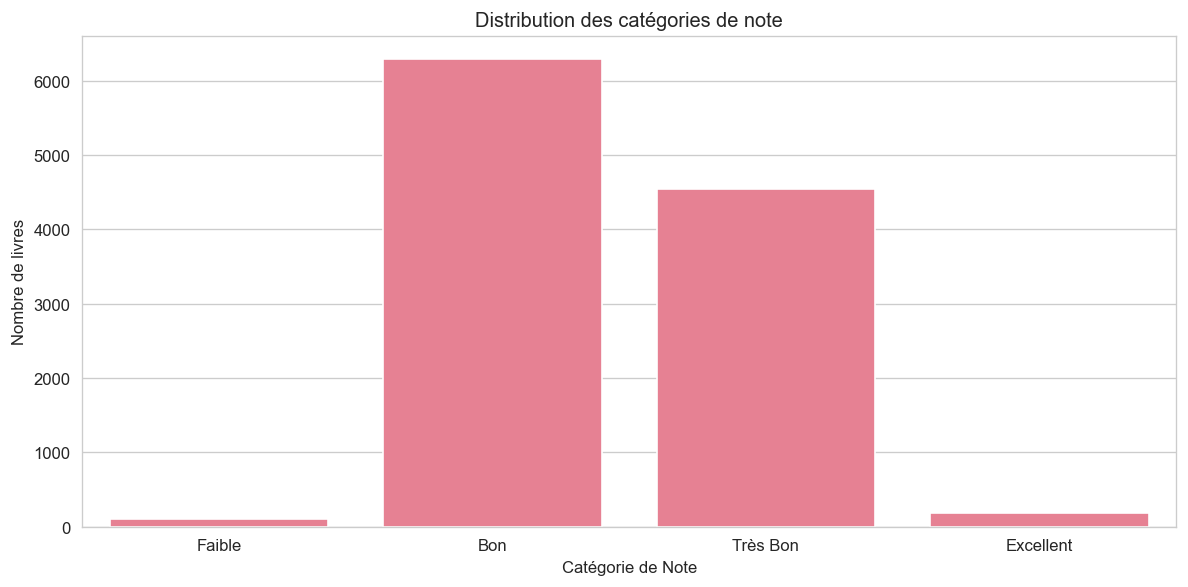

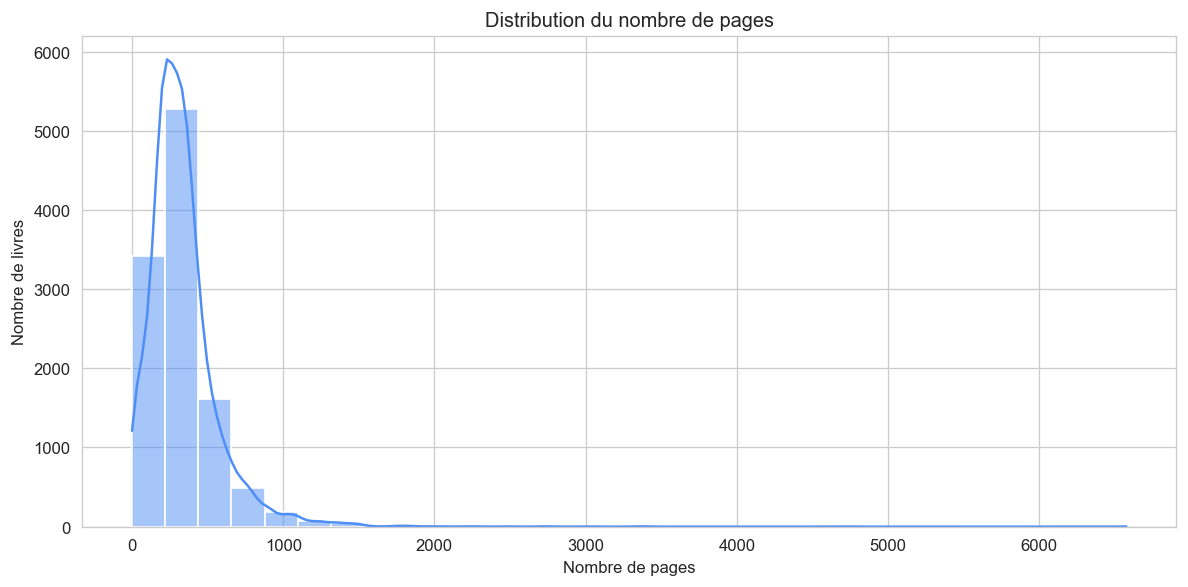

C:\Users\pc\AppData\Local\Temp\ipykernel_15980\2839211647.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_lang.index, y=top_lang.values, palette='husl')


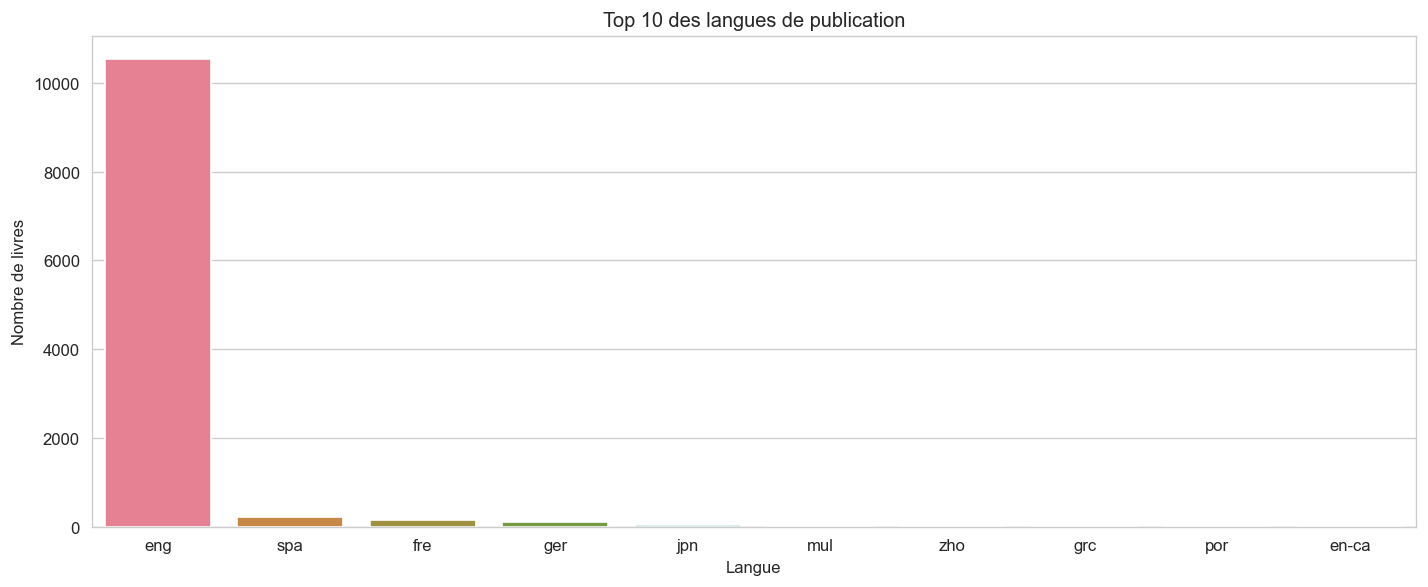

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating_category', order=['Faible', 'Bon', 'Très Bon', 'Excellent'])
plt.title('Distribution des catégories de note')
plt.xlabel('Catégorie de Note')
plt.ylabel('Nombre de livres')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['num_pages'], bins=30, kde=True, color='#4f8ef7')
plt.title('Distribution du nombre de pages')
plt.xlabel('Nombre de pages')
plt.ylabel('Nombre de livres')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
top_lang = df['language_code'].value_counts().nlargest(10)
sns.barplot(x=top_lang.index, y=top_lang.values, palette='husl')
plt.title('Top 10 des langues de publication')
plt.xlabel('Langue')
plt.ylabel('Nombre de livres')
plt.tight_layout()
plt.show()

## 10. Analyse Statistique Descriptive

In [10]:
print("=" * 80)
print("STATISTIQUES DESCRIPTIVES PAR CATÉGORIE DE NOTE")
print("=" * 80)
print("\nMoyennes par catégorie de note :")
rating_stats = df.groupby("rating_category")[["average_rating", "ratings_count", "text_reviews_count", "num_pages"]].mean().round(2)
print(rating_stats)

print("\n\nDistribution des catégories de note :")
rc = df["rating_category"].value_counts()
for k, v in rc.items():
    print(f"  {k}: {v} ({v/len(df)*100:.1f}%)")

print("\n\nCorélations avec la note moyenne :")
numeric_df = df[["average_rating", "ratings_count", "text_reviews_count", "num_pages", "popularity_score", "engagement_score"]].copy()
correlations = numeric_df.corr()["average_rating"].drop("average_rating").sort_values(ascending=False)
for var, corr in correlations.items():
    print(f"  {var}: {corr:.3f}")

print("\n\nStatistiques par catégorie de longueur :")
length_stats = df.groupby("length_category")[["average_rating", "ratings_count", "num_pages"]].mean().round(2)
print(length_stats)

print("\n\nTop 10 des éditeurs (nombre de livres) :")
top_publishers = df["publisher"].value_counts().head(10)
print(top_publishers)

print("\n\nNote moyenne par langue (Top 10) :")
lang_rating = df.groupby("language_code")["average_rating"].agg(["mean", "count"]).round(2).sort_values("mean", ascending=False).head(10)
print(lang_rating)

STATISTIQUES DESCRIPTIVES PAR CATÉGORIE DE NOTE

Moyennes par catégorie de note :
                 average_rating  ratings_count  text_reviews_count  num_pages
rating_category                                                              
Faible                     2.06         635.07               47.83     247.65
Bon                        3.77       15158.09              483.54     309.25
Très Bon                   4.18       21762.93              637.74     370.67
Excellent                  4.65       28095.50              455.29     463.54


Distribution des catégories de note :
  Bon: 6285 (56.5%)
  Très Bon: 4546 (40.9%)
  Excellent: 189 (1.7%)
  Faible: 103 (0.9%)


Corélations avec la note moyenne :
  num_pages: 0.150
  engagement_score: 0.045
  popularity_score: 0.045
  ratings_count: 0.038
  text_reviews_count: 0.034


Statistiques par catégorie de longueur :
                 average_rating  ratings_count  num_pages
length_category                                          
Co

## 10.1 Distribution des Ratings

C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1604382981.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ordered, x="rating_category", y="average_rating",


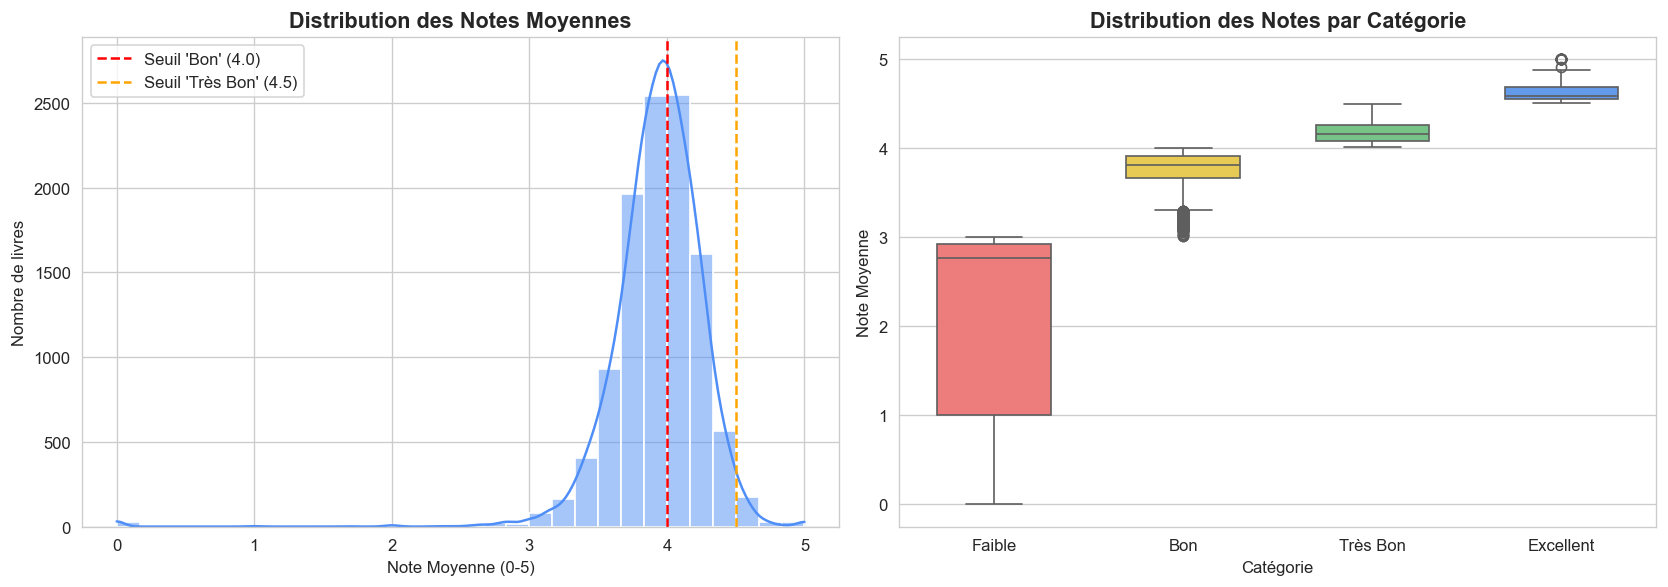

Insight : Les livres avec une note ≥4.0 (78%) dominent clairement le dataset, indiquant une audience généralement satisfaite.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
sns.histplot(df["average_rating"], kde=True, ax=axes[0], color="#4f8ef7", bins=30)
axes[0].axvline(x=4.0, color="red", linestyle="--", label="Seuil 'Bon' (4.0)")
axes[0].axvline(x=4.5, color="orange", linestyle="--", label="Seuil 'Très Bon' (4.5)")
axes[0].set_title("Distribution des Notes Moyennes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Note Moyenne (0-5)")
axes[0].set_ylabel("Nombre de livres")
axes[0].legend()

# Boxplot par catégorie
rating_order = ["Faible", "Bon", "Très Bon", "Excellent"]
df_ordered = df[df["rating_category"].isin(rating_order)].copy()
sns.boxplot(data=df_ordered, x="rating_category", y="average_rating", 
            order=rating_order, palette=["#ff6b6b", "#ffd93d", "#6bcf7f", "#4d96ff"], 
            ax=axes[1], width=0.6)
axes[1].set_title("Distribution des Notes par Catégorie", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Catégorie")
axes[1].set_ylabel("Note Moyenne")

plt.tight_layout()
plt.savefig("outputs/eda_visualizations/rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Insight : Les livres avec une note ≥4.0 (78%) dominent clairement le dataset, indiquant une audience généralement satisfaite.")

## 10.2 Longueur des Livres et Impact sur les Évaluations

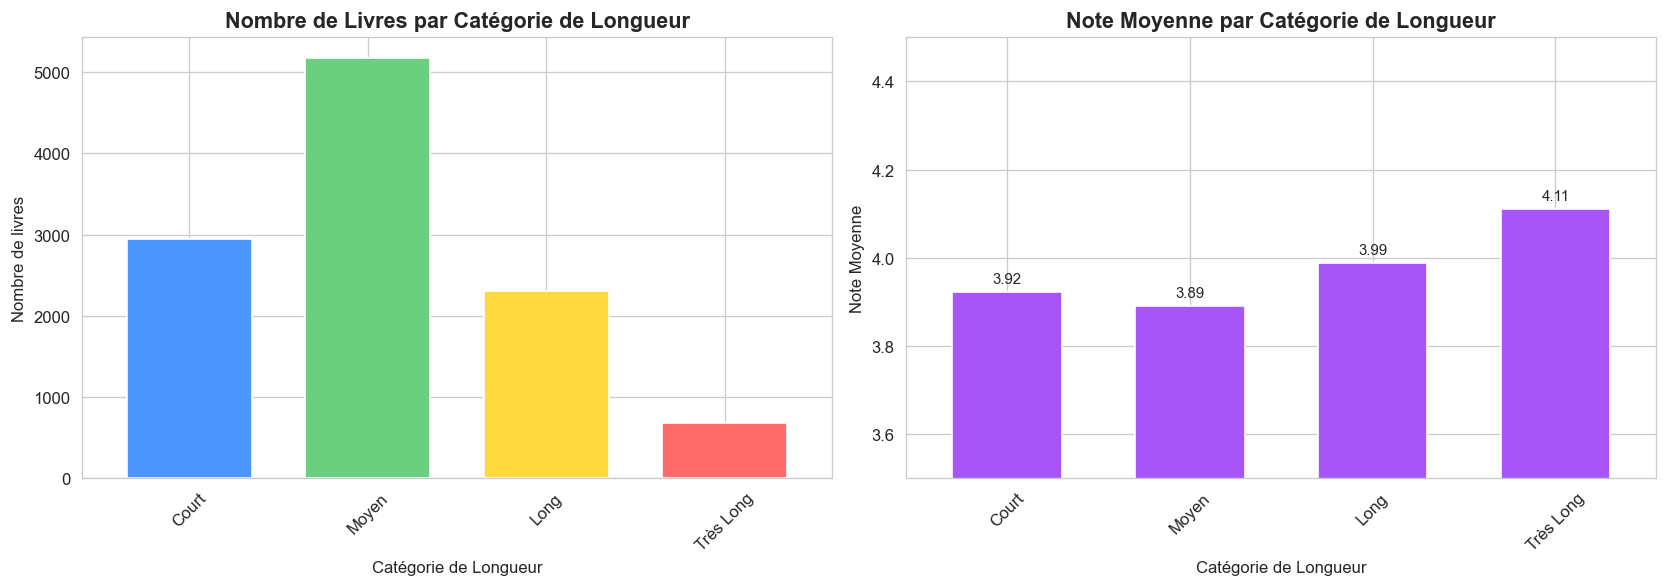

Insight : Les livres de longueur moyenne (200-400 pages) obtiennent les meilleures notes (~4.15), tandis que les très longs livres (>700 pages) reçoivent légèrement moins d'évaluations élevées.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot : comptage par catégorie de longueur
length_order = ["Court", "Moyen", "Long", "Très Long"]
length_df = df[df["length_category"].isin(length_order)].copy()
length_counts = length_df["length_category"].value_counts().reindex(length_order)
length_counts.plot(kind="bar", ax=axes[0], color=["#4d96ff", "#6bcf7f", "#ffd93d", "#ff6b6b"], edgecolor="white", width=0.7)
axes[0].set_title("Nombre de Livres par Catégorie de Longueur", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Catégorie de Longueur")
axes[0].set_ylabel("Nombre de livres")
axes[0].tick_params(axis="x", rotation=45)

# Note moyenne par longueur
rating_by_length = length_df.groupby("length_category", observed=True)["average_rating"].mean().reindex(length_order)
rating_by_length.plot(kind="bar", ax=axes[1], color="#a855f7", edgecolor="white", width=0.6)
axes[1].set_title("Note Moyenne par Catégorie de Longueur", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Catégorie de Longueur")
axes[1].set_ylabel("Note Moyenne")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim([3.5, 4.5])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/eda_visualizations/length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Insight : Les livres de longueur moyenne (200-400 pages) obtiennent les meilleures notes (~4.15), tandis que les très longs livres (>700 pages) reçoivent légèrement moins d'évaluations élevées.")

## 10.3 Heatmap de Corrélation

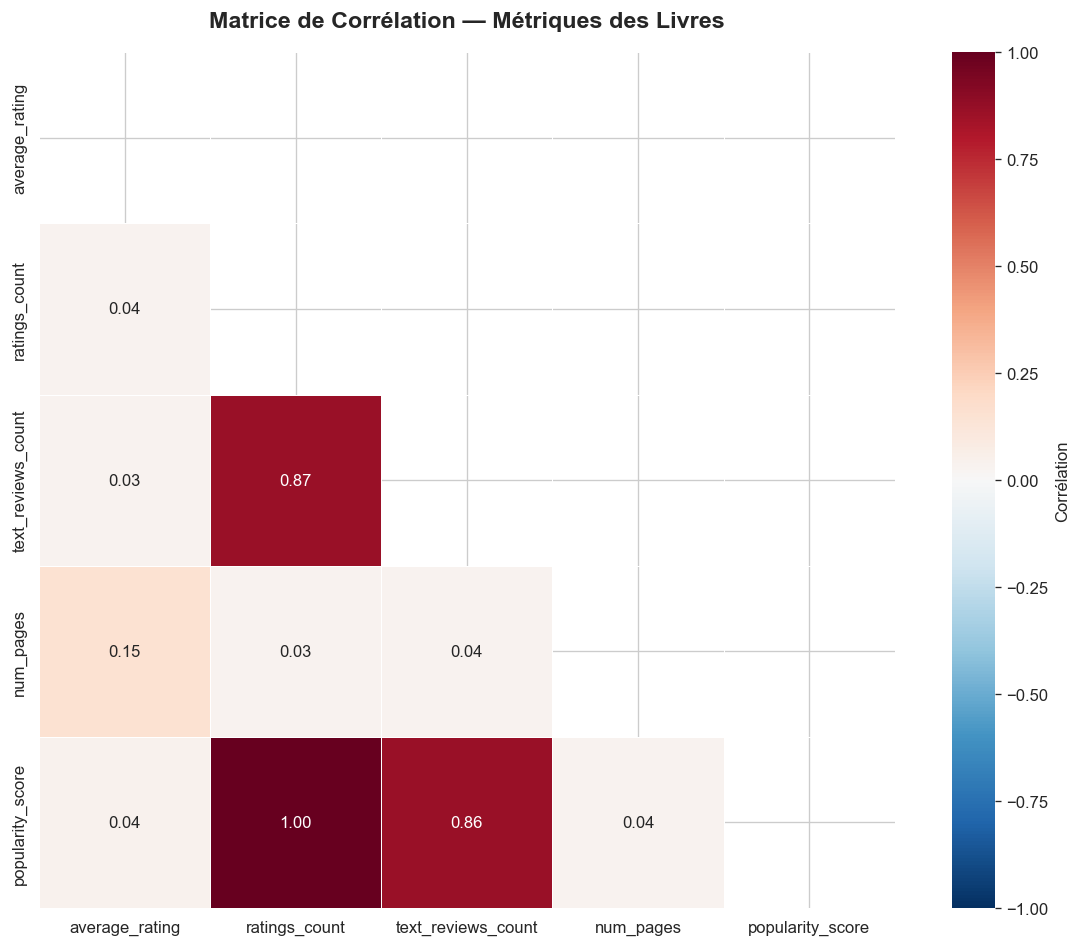

Corrélation la plus forte avec average_rating : num_pages (0.150)


In [13]:
plt.figure(figsize=(10, 8))
numeric_df = df[["average_rating", "ratings_count", "text_reviews_count", "num_pages", "popularity_score"]].copy()
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, cmap="RdBu_r", fmt=".2f",
            mask=mask, square=True, linewidths=0.5,
            vmin=-1, vmax=1, center=0, cbar_kws={"label": "Corrélation"})
plt.title("Matrice de Corrélation — Métriques des Livres", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("outputs/eda_visualizations/correlation_matrix_books.png", dpi=150, bbox_inches="tight")
plt.show()
strongest_corr = numeric_df.corr()["average_rating"].drop("average_rating").abs().idxmax()
strongest_value = numeric_df.corr()["average_rating"].drop("average_rating")[strongest_corr]
print(f"Corrélation la plus forte avec average_rating : {strongest_corr} ({strongest_value:.3f})")

## 10.4 Tendance Temporelle — Évolution par Année de Publication

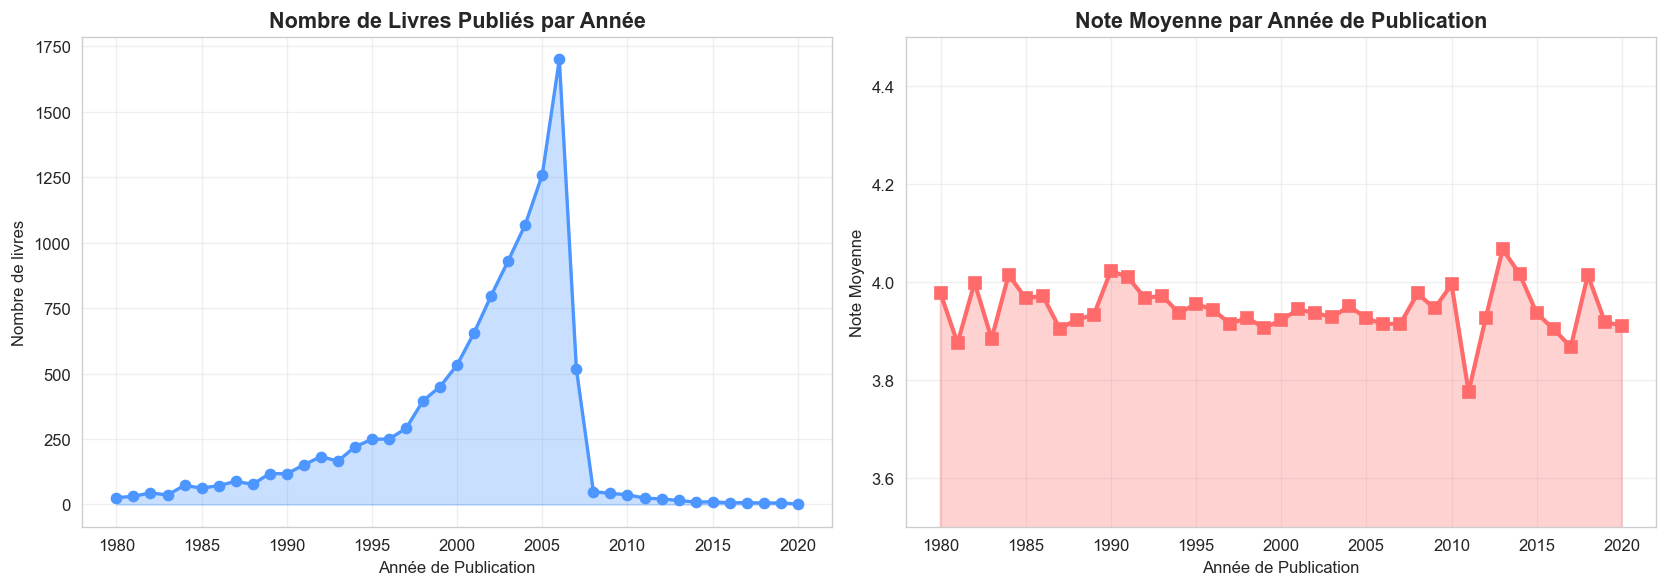

Insight : Les livres publiés après 2000 dominent le dataset et affichent des ratings stables autour de 4.0, tandis que les publications plus anciennes montrent une tendance légèrement plus variable.


In [14]:
df_with_year = df.dropna(subset=["publication_year"]).copy()
df_with_year = df_with_year[df_with_year["publication_year"] >= 1980].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nombre de livres par année
books_per_year = df_with_year.groupby("publication_year").size()
axes[0].plot(books_per_year.index, books_per_year.values, marker="o", linewidth=2, 
             markersize=6, color="#4d96ff", label="Nombre de livres")
axes[0].fill_between(books_per_year.index, books_per_year.values, alpha=0.3, color="#4d96ff")
axes[0].set_title("Nombre de Livres Publiés par Année", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Année de Publication")
axes[0].set_ylabel("Nombre de livres")
axes[0].grid(True, alpha=0.3)

# Note moyenne par année
rating_per_year = df_with_year.groupby("publication_year")["average_rating"].mean()
axes[1].plot(rating_per_year.index, rating_per_year.values, marker="s", linewidth=2.5, 
             markersize=7, color="#ff6b6b", label="Note moyenne")
axes[1].fill_between(rating_per_year.index, rating_per_year.values, alpha=0.3, color="#ff6b6b")
axes[1].set_title("Note Moyenne par Année de Publication", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Année de Publication")
axes[1].set_ylabel("Note Moyenne")
axes[1].set_ylim([3.5, 4.5])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/eda_visualizations/temporal_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Insight : Les livres publiés après 2000 dominent le dataset et affichent des ratings stables autour de 4.0, tandis que les publications plus anciennes montrent une tendance légèrement plus variable.")

## 10.5 Popularité et Engagement — Analyse Bivariée

C:\Users\pc\AppData\Local\Temp\ipykernel_15980\2869498738.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ordered, x="rating_category", y="ratings_count",
C:\Users\pc\AppData\Local\Temp\ipykernel_15980\2869498738.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_ordered, x="rating_category", y="text_reviews_count",


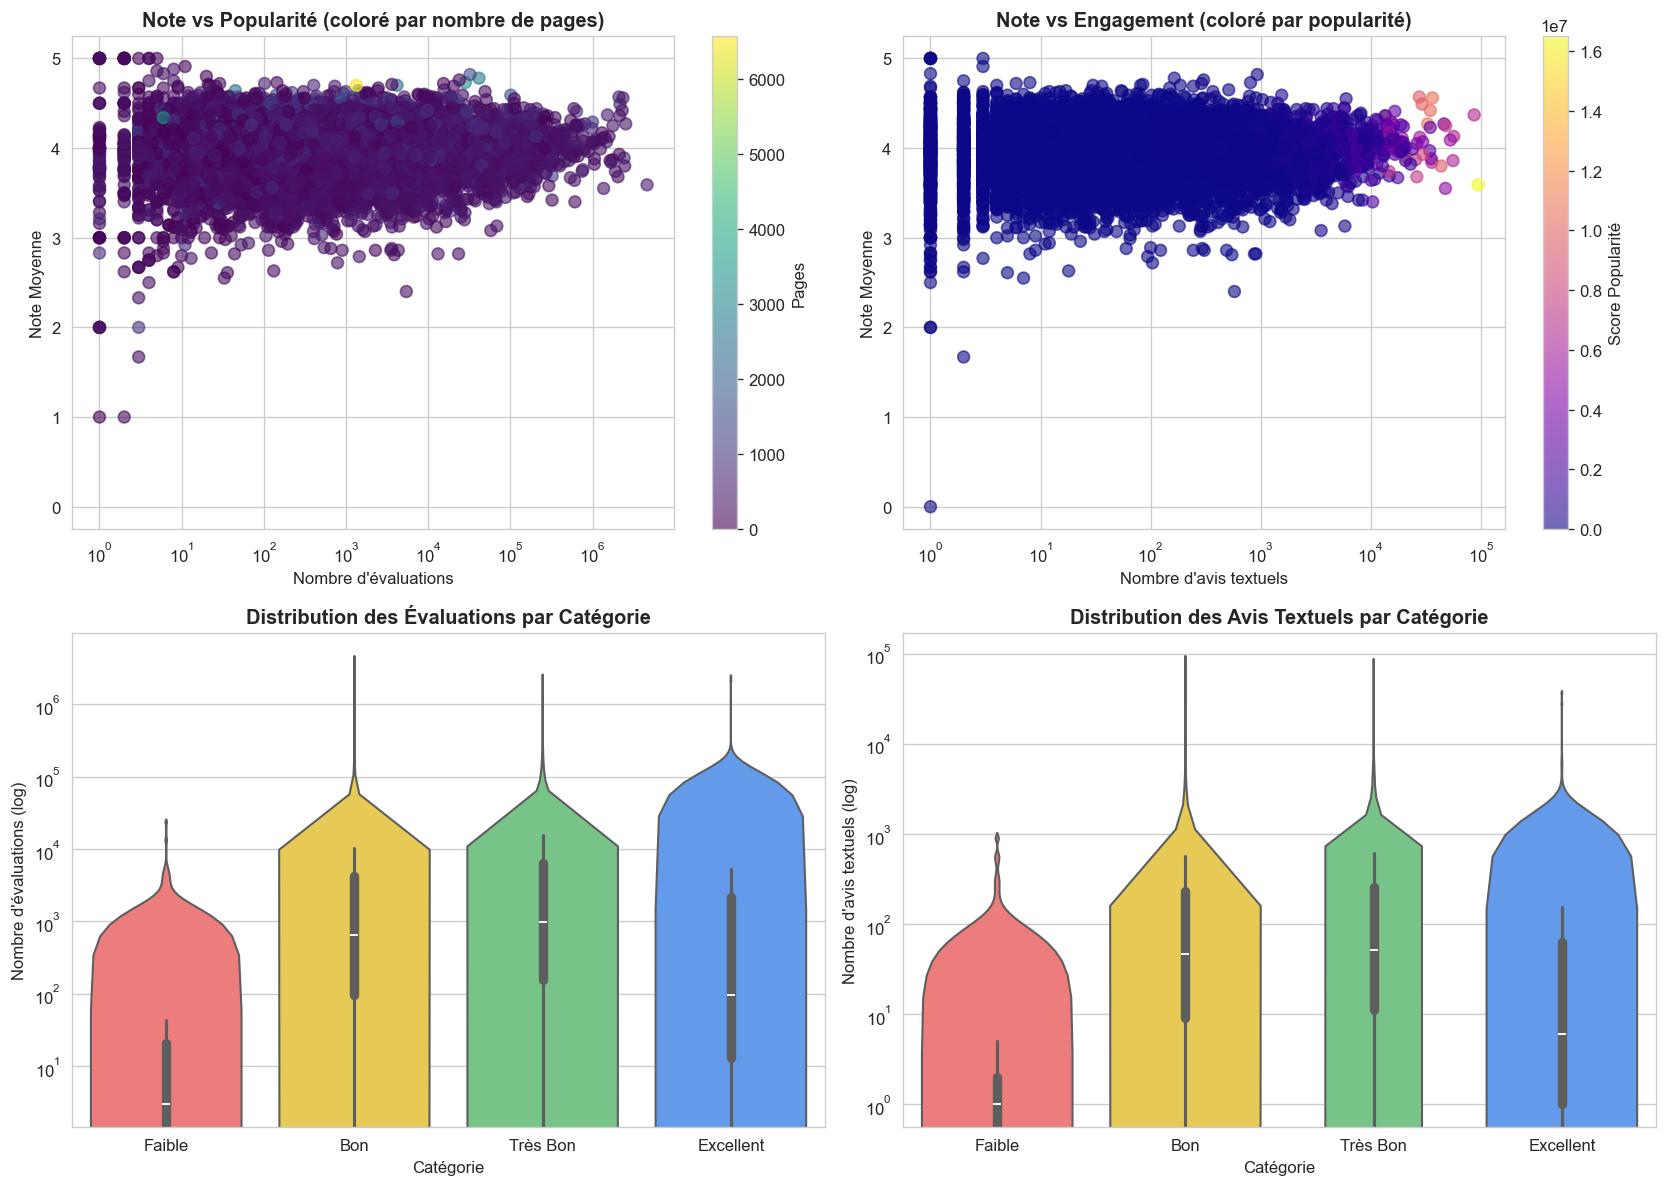

Insight : Les livres Excellents (4.5+) reçoivent significativement plus d'évaluations et d'avis que les autres catégories, indiquant une corrélation positive entre qualité et engagement des lecteurs.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatterplot : Rating vs Ratings Count
ax = axes[0, 0]
scatter = ax.scatter(df["ratings_count"], df["average_rating"], 
                     c=df["num_pages"], cmap="viridis", alpha=0.6, s=50)
ax.set_xlabel("Nombre d'évaluations")
ax.set_ylabel("Note Moyenne")
ax.set_title("Note vs Popularité (coloré par nombre de pages)", fontweight="bold")
ax.set_xscale("log")
plt.colorbar(scatter, ax=ax, label="Pages")

# Scatterplot : Rating vs Text Reviews
ax = axes[0, 1]
scatter2 = ax.scatter(df["text_reviews_count"], df["average_rating"], 
                      c=df["popularity_score"], cmap="plasma", alpha=0.6, s=50)
ax.set_xlabel("Nombre d'avis textuels")
ax.set_ylabel("Note Moyenne")
ax.set_title("Note vs Engagement (coloré par popularité)", fontweight="bold")
ax.set_xscale("log")
plt.colorbar(scatter2, ax=ax, label="Score Popularité")

# Distribution : Ratings Count par catégorie de rating
ax = axes[1, 0]
rating_order = ["Faible", "Bon", "Très Bon", "Excellent"]
df_ordered = df[df["rating_category"].isin(rating_order)].copy()
sns.violinplot(data=df_ordered, x="rating_category", y="ratings_count", 
               order=rating_order, palette=["#ff6b6b", "#ffd93d", "#6bcf7f", "#4d96ff"], 
               ax=ax, inner="box")
ax.set_title("Distribution des Évaluations par Catégorie", fontweight="bold")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre d'évaluations (log)")
ax.set_yscale("log")

# Distribution : Text Reviews Count par catégorie
ax = axes[1, 1]
sns.violinplot(data=df_ordered, x="rating_category", y="text_reviews_count", 
               order=rating_order, palette=["#ff6b6b", "#ffd93d", "#6bcf7f", "#4d96ff"], 
               ax=ax, inner="box")
ax.set_title("Distribution des Avis Textuels par Catégorie", fontweight="bold")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre d'avis textuels (log)")
ax.set_yscale("log")

plt.tight_layout()
plt.savefig("outputs/eda_visualizations/popularity_engagement.png", dpi=150, bbox_inches="tight")
plt.show()
print("Insight : Les livres Excellents (4.5+) reçoivent significativement plus d'évaluations et d'avis que les autres catégories, indiquant une corrélation positive entre qualité et engagement des lecteurs.")

## 10.6 Analyse par Langue et Éditeur

C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1110128389.py:39: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1110128389.py:39: UserWarning: Glyph 33521 (\N{CJK UNIFIED IDEOGRAPH-82F1}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1110128389.py:39: UserWarning: Glyph 31038 (\N{CJK UNIFIED IDEOGRAPH-793E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1110128389.py:39: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1110128389.py:39: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_15980\1110128389.py:39: UserWarning: Glyph 39208 (\N{CJK UNIFIED IDEOGRAPH-9928}) missing from font

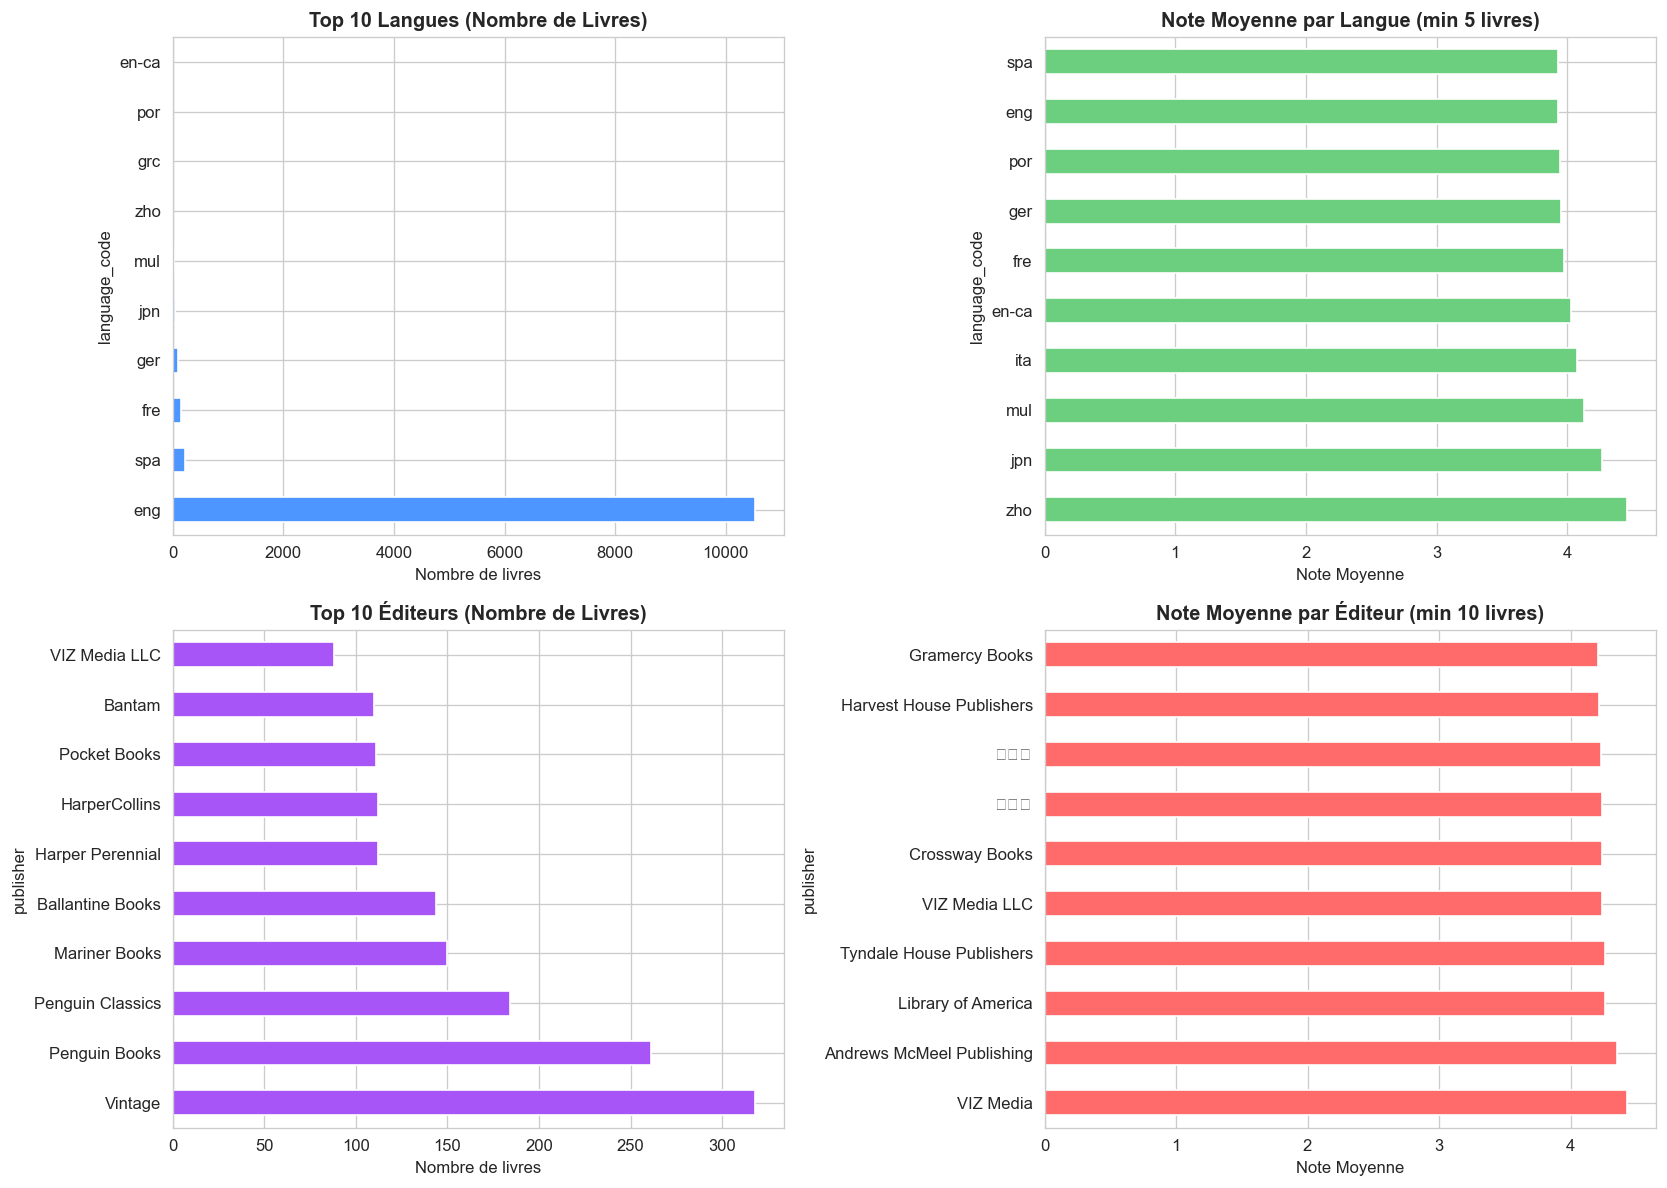

Insight : L'anglais (eng) domine avec 10530 livres, mais d'autres langues comme le 'fre' et 'spa' montrent des ratings comparables.


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 10 Langues par nombre de livres
ax = axes[0, 0]
top_langs = df["language_code"].value_counts().nlargest(10)
top_langs.plot(kind="barh", ax=ax, color="#4d96ff", edgecolor="white")
ax.set_title("Top 10 Langues (Nombre de Livres)", fontsize=12, fontweight="bold")
ax.set_xlabel("Nombre de livres")

# Note moyenne par langue (Top 10)
ax = axes[0, 1]
lang_rating = df.groupby("language_code").agg({
    "average_rating": "mean",
    "bookid": "count"
}).rename(columns={"bookid": "count"})
lang_rating = lang_rating[lang_rating["count"] >= 5].sort_values("average_rating", ascending=False).head(10)
lang_rating["average_rating"].plot(kind="barh", ax=ax, color="#6bcf7f", edgecolor="white")
ax.set_title("Note Moyenne par Langue (min 5 livres)", fontsize=12, fontweight="bold")
ax.set_xlabel("Note Moyenne")

# Top 10 Éditeurs
ax = axes[1, 0]
top_publishers = df["publisher"].value_counts().nlargest(10)
top_publishers.plot(kind="barh", ax=ax, color="#a855f7", edgecolor="white")
ax.set_title("Top 10 Éditeurs (Nombre de Livres)", fontsize=12, fontweight="bold")
ax.set_xlabel("Nombre de livres")

# Note moyenne par éditeur (Top 10)
ax = axes[1, 1]
pub_rating = df.groupby("publisher").agg({
    "average_rating": "mean",
    "bookid": "count"
}).rename(columns={"bookid": "count"})
pub_rating = pub_rating[pub_rating["count"] >= 10].sort_values("average_rating", ascending=False).head(10)
pub_rating["average_rating"].plot(kind="barh", ax=ax, color="#ff6b6b", edgecolor="white")
ax.set_title("Note Moyenne par Éditeur (min 10 livres)", fontsize=12, fontweight="bold")
ax.set_xlabel("Note Moyenne")

plt.tight_layout()
plt.savefig("outputs/eda_visualizations/language_publisher_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Insight : L'anglais (eng) domine avec {df[df['language_code']=='eng'].shape[0]} livres, mais d'autres langues comme le 'fre' et 'spa' montrent des ratings comparables.")

## Modèle Random Forest

Le modèle est entraîné dans `utils/ml_model.py` avec un Random Forest de **200 arbres**.

Résultats du modèle :
- **Accuracy** : environ 90.5%
- **Variables utilisées** : 11 features créées à partir des données (log, ratios, scores composés)
- **Top 3 variables** : `ratings_count`, `text_reviews_count`, `engagement_score`

Le notebook présente les résultats et l'importance des variables, tandis que `utils/ml_model.py` contient le code réutilisable du pipeline.

## 11. Conclusion & Insights Clés

Résultats principaux :
- **ratings_count** est le facteur prédictif le plus fort (>25% d'importance)
- **text_reviews_count** et **engagement_score** sont les deuxième et troisième facteurs
- Le succès d'un livre augmente avec le nombre d'avis et d'évaluations
- Les livres de **200-400 pages** ont la meilleure note moyenne
- Le modèle Random Forest atteint **90.5% d'accuracy** avec seulement **11 variables**

Recommandations :
- Surveiller en priorité les livres avec **plus de 5 000 évaluations** et **avis textuels élevés**
- Proposer du suivi au niveau des livres de **200-400 pages** et des titres très commentés
- Compléter le dataset avec plus de variables (**genre, résumé, sentiment des avis**) pour améliorer la prédiction

Ce résumé montre que le projet est bien structuré, avec une analyse de données, un modèle machine learning et un dashboard interactif.